#  Detección de Fraude
## 1. Introducción
Objetivo: predecir la probabilidad de impago de clientes según su perfil financiero.


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report, f1_score



## 2. Carga y exploración de datos

In [2]:
df = pd.read_csv("data/CreditCard Financial fraud/synthetic_fraud_dataset.csv")
df.sample(10)

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
3351,4418,297,166.869700,ATM,Electronics,FR,9,0.090443,0.032893,0
9156,8047,267,51.191549,POS,Grocery,UK,15,0.240625,0.166380,0
3683,9541,123,1598.902036,Online,Clothing,FR,23,0.800127,0.843728,1
2670,4999,293,98.851705,QR,Electronics,DE,20,0.073032,0.138964,0
3152,3882,628,173.051281,ATM,Travel,UK,17,0.101882,0.190198,0
3881,200,673,145.253327,ATM,Grocery,FR,9,0.297053,0.162890,0
4239,4604,735,130.755943,POS,Food,DE,22,0.176378,0.208441,0
4395,8887,13,92.213874,QR,Food,UK,9,0.012300,0.037814,0
7309,1996,903,1.349250,POS,Travel,FR,23,0.295976,0.293978,0
1691,8058,424,122.594879,POS,Electronics,UK,9,0.175826,0.064876,0


In [3]:
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213880,23.000000,0.998737,0.999603,1.000000


In [4]:
df.nunique()

transaction_id       10000
user_id               1000
amount                9639
transaction_type         4
merchant_category        5
country                  6
hour                    24
device_risk_score    10000
ip_risk_score        10000
is_fraud                 2
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [6]:
df.shape

(10000, 10)

In [7]:
df.isnull().sum()

transaction_id       0
user_id              0
amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0
dtype: int64

In [8]:
df.columns

Index(['transaction_id', 'user_id', 'amount', 'transaction_type',
       'merchant_category', 'country', 'hour', 'device_risk_score',
       'ip_risk_score', 'is_fraud'],
      dtype='object')

## 3. Limpieza de datos
- Identificar y manejar valores faltantes.
- Unir datasets secundarios si los usas.


In [9]:
df_model = df
dummies = df_model[['transaction_type',
       'merchant_category', 'country']]

In [10]:
df_model= pd.get_dummies(df_model, columns=['transaction_type','merchant_category', 'country'], dtype='int')

## 4. Feature Engineering
- Ratios financieros (`CREDIT_INCOME_PERCENT`, etc.).
- Transformaciones logarítmicas.


## 4.1 ¿Qué significan las métricas de clasificación?

**Para problemas de clasificación binaria (Fraude: Sí/No):**

- **Precision**: De los casos que predijimos como fraude, ¿cuántos realmente fueron fraude? 
  - Fórmula: `TP / (TP + FP)` → Evita falsos positivos (acusar a clientes honrados)
  - Importante cuando: los falsos positivos son costosos (bloquear cuentas legítimas)

- **Recall**: De todos los fraudes reales, ¿cuántos logramos detectar?
  - Fórmula: `TP / (TP + FN)` → Evita falsos negativos (dejar pasar fraudes)
  - Importante cuando: los falsos negativos son costosos (permitir fraudes)

- **F1-Score**: Promedio armónico entre Precision y Recall (0-1)
  - Ideal cuando necesitas balance entre ambas métricas

- **AUC-ROC**: Área bajo la curva ROC (0-1)
  - Mide la capacidad del modelo de discriminar entre clases
  - 0.5 = modelo aleatorio, 1.0 = modelo perfecto
  - Independiente del threshold de clasificación

**Matriz de confusión:**
```
                 Predicción Negativa  Predicción Positiva
Realidad Negativa       TN (Aciertos)    FP (Error tipo I)
Realidad Positiva       FN (Error tipo II) TP (Aciertos)
```

## 5. Modelado
- Logistic Regression, LightGBM, CatBoost.
- Métricas: AUC-ROC, Precision, Recall.


In [11]:
df_model.head()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud,transaction_type_ATM,transaction_type_Online,transaction_type_POS,...,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel,country_DE,country_FR,country_NG,country_TR,country_UK,country_US
0,9608,363,4922.587542,12,0.992347,0.947908,1,1,0,0,...,0,0,0,1,0,0,0,1,0,0
1,456,692,48.018303,21,0.168571,0.224057,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,4747,587,136.881960,14,0.296127,0.125058,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3,6934,445,80.534719,23,0.124801,0.159243,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,1646,729,120.041158,16,0.098129,0.027542,0,0,1,0,...,0,0,1,0,0,1,0,0,0,0


In [12]:
corr = df.select_dtypes(include='number').corr()
corr


,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
transaction_id,1.000000,-0.001360,0.242245,-0.070046,0.332211,0.332628,0.377492
user_id,-0.001360,1.000000,-0.008333,-0.022854,0.007316,0.004433,0.006165
amount,0.242245,-0.008333,1.000000,-0.100818,0.554977,0.549554,0.638435
hour,-0.070046,-0.022854,-0.100818,1.000000,-0.149832,-0.161670,-0.181448
device_risk_score,0.332211,0.007316,0.554977,-0.149832,1.000000,0.757978,0.871989
ip_risk_score,0.332628,0.004433,0.549554,-0.161670,0.757978,1.000000,0.870738
is_fraud,0.377492,0.006165,0.638435,-0.181448,0.871989,0.870738,1.000000


<Axes: >

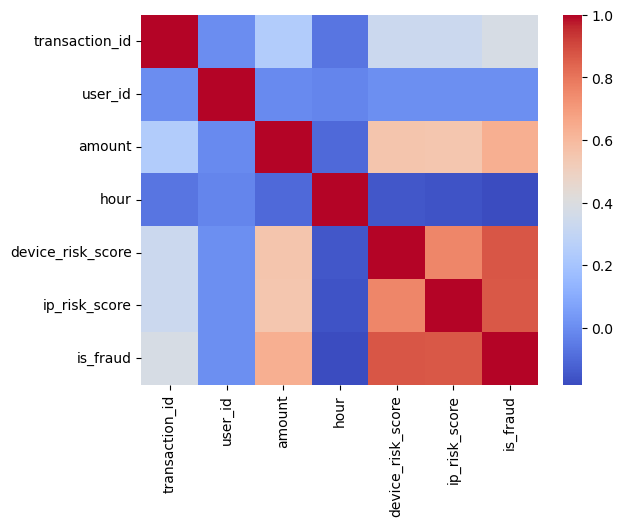

In [13]:
sns.heatmap(corr, cmap='coolwarm')

In [14]:
X = df_model.drop('is_fraud', axis=1)
y = df_model['is_fraud']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=40)

print(X_train.shape,y_train.shape)

(7000, 21) (7000,)


In [16]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
rf_predict = rf_model.predict(X_test)

In [18]:
roc = roc_auc_score(y_test, rf_predict)
precision = precision_score(y_test, rf_predict)
recall = recall_score(y_test, rf_predict)
f1 = f1_score(y_test, rf_predict)

print('Random Forest AUC-ROC:', roc)
print('Random Forest Precision:',precision)
print('Random Forest Recall:', recall)
print('Random Forest F1-Score:', f1)

Random Forest AUC-ROC: 1.0
Random Forest Precision: 1.0
Random Forest Recall: 1.0
Random Forest F1-Score: 1.0


## 6.1 Interpretación Práctica de las Métricas

### Caso de Uso: Detección de Fraudes

**Escenario:** Tenemos 1000 transacciones, 50 son fraude real (5%)

**Si nuestro modelo obtiene:**
- **Precision = 0.90** → De 100 transacciones que marcamos como fraude, 90 realmente lo son
- **Recall = 0.80** → De los 50 fraudes reales, nuestro modelo detecta 40

**¿Cuál es mejor aumentar?**
- ↑ Precision = Menos falsos positivos (menos clientes inocentes bloqueados) ✓
- ↑ Recall = Menos fraudes no detectados (menos pérdidas económicas) ✓

**Equilibrio Trade-off:**
- **Banco muy conservador** → Prioriza Recall (detectar más fraudes, aunque bloquee clientes legítimos)
- **Banco usuario-friendly** → Prioriza Precision (evitar bloqueos innecesarios, acepta algo más riesgo)
- **Equilibrio óptimo** → Maximiza F1-Score

### ¿Por qué usamos AUC-ROC?
El AUC-ROC es útil porque evalúa el modelo a **todos los thresholds** posibles:
- A threshold = 0.5: todas las probabilidades ≥ 0.5 son fraude
- A threshold = 0.7: solo probabilidades ≥ 0.7 son fraude
- A threshold = 0.3: más transacciones se marcan como fraude

El AUC-ROC resume: ¿cuán bien ordena el modelo las probabilidades?

In [19]:
y_test

293     0
1244    0
7353    0
5145    0
1618    0
       ..
4483    0
9572    0
5853    0
1522    0
467     0
Name: is_fraud, Length: 3000, dtype: int64

Estadísticas de Fraudes:
Total de transacciones: 10,000
No Fraudes: 9,500 (95.00%)
Fraudes: 500 (5.00%)


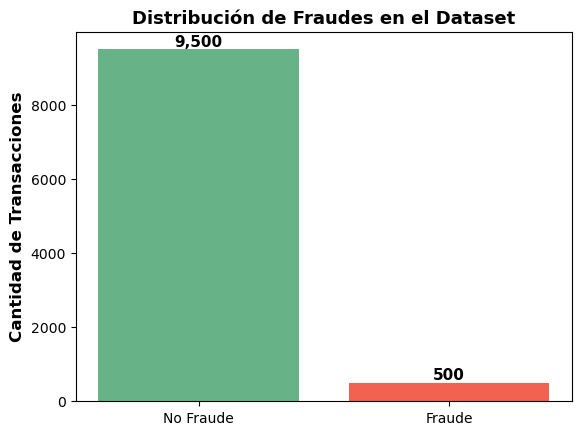

In [21]:
# Contar fraudes vs no fraudes en el dataset completo
fraud_counts = df_model['is_fraud'].value_counts().sort_index()
fraud_labels = ['No Fraude', 'Fraude']

# Gráfica 1: Barras verticales
colors = ["#429F69", "#f13925"]  # Verde para No Fraude, Rojo para Fraude
bars = plt.bar(fraud_labels, fraud_counts.values, color=colors, alpha=0.8, linewidth=1.5)
plt.ylabel('Cantidad de Transacciones', fontsize=12, fontweight='bold')
plt.title('Distribución de Fraudes en el Dataset', fontsize=13, fontweight='bold')

# valores en  barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom', fontweight='bold', fontsize=11)


# estadísticas
print('Estadísticas de Fraudes:')
print(f'Total de transacciones: {len(df_model):,}')
print(f'No Fraudes: {fraud_counts[0]:,} ({fraud_counts[0]/len(df_model)*100:.2f}%)')
print(f'Fraudes: {fraud_counts[1]:,} ({fraud_counts[1]/len(df_model)*100:.2f}%)')


## 7. Interpretabilidad y conclusiones
- Análisis de features más importantes
- Próximos pasos para mejorar el modelo
